In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
import pandas as pd

## Fit spectrum data and get center wavelength & FWHM

In [2]:
# --- Define Gaussian with offsets ---
def gauss(x, a, x0, sigma, y0):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + y0

# --- Path to your folder ---
#path = r"C:\\Users\\miria\\OneDrive\\Dokumente\\Studium\\Master\\Kurse\\Masterarbeit\\OPACharacterisation\\spectra_txt"
path = r"spectra_txt"

# --- Function to compute weighted mean and error ---
def weighted_mean(values, errors):
    weights = 1/np.array(errors)**2
    mean = np.sum(values * weights) / np.sum(weights)
    err = np.sqrt(1/np.sum(weights))
    return mean, err

  sigma = 19.8391 ± 0.0788
  sigma = 20.5022 ± 0.0986
  sigma = 19.8648 ± 0.1004
  sigma = 19.4930 ± 0.0956


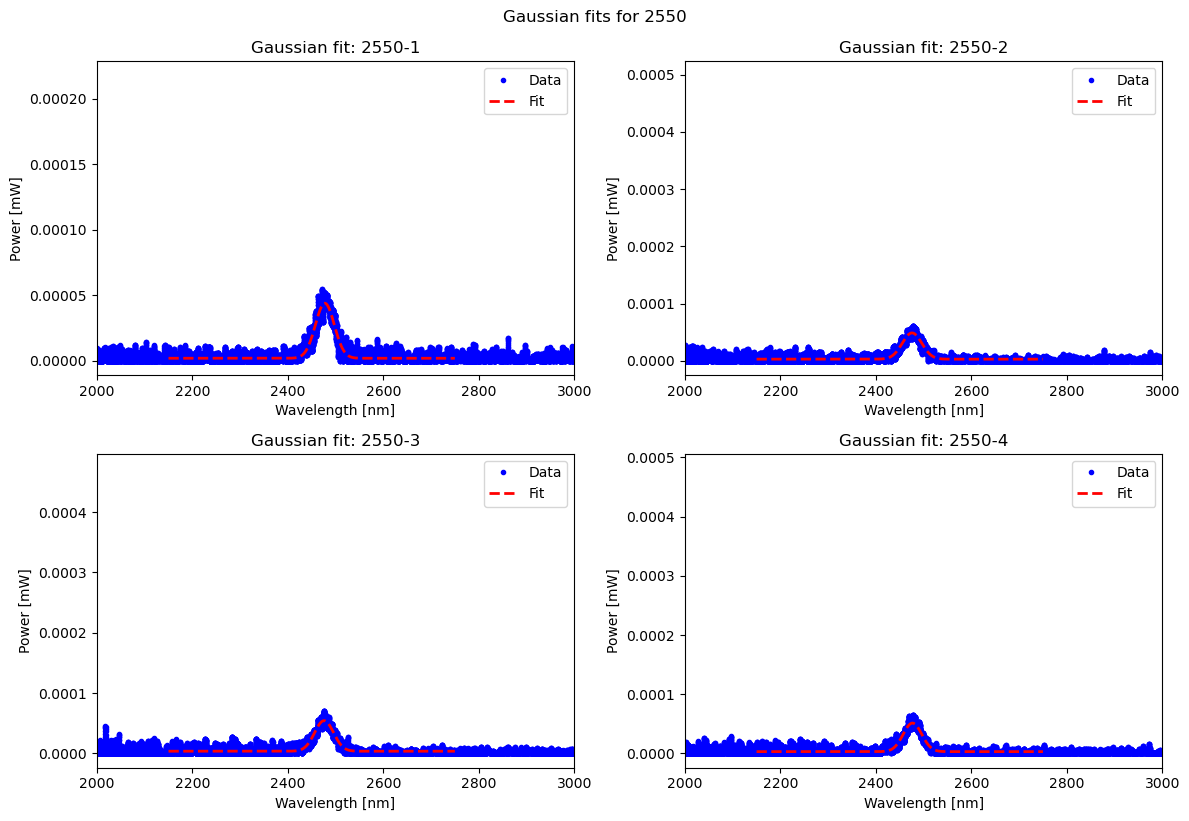

Summary for set 2550:
Mean x0    = 2476.6255 ± 0.0427
Mean sigma = 19.9088 ± 0.0460
  sigma = 22.4042 ± 0.1111
  sigma = 23.0255 ± 0.1102
  sigma = 21.0122 ± 0.1095
  sigma = 20.6709 ± 0.1046


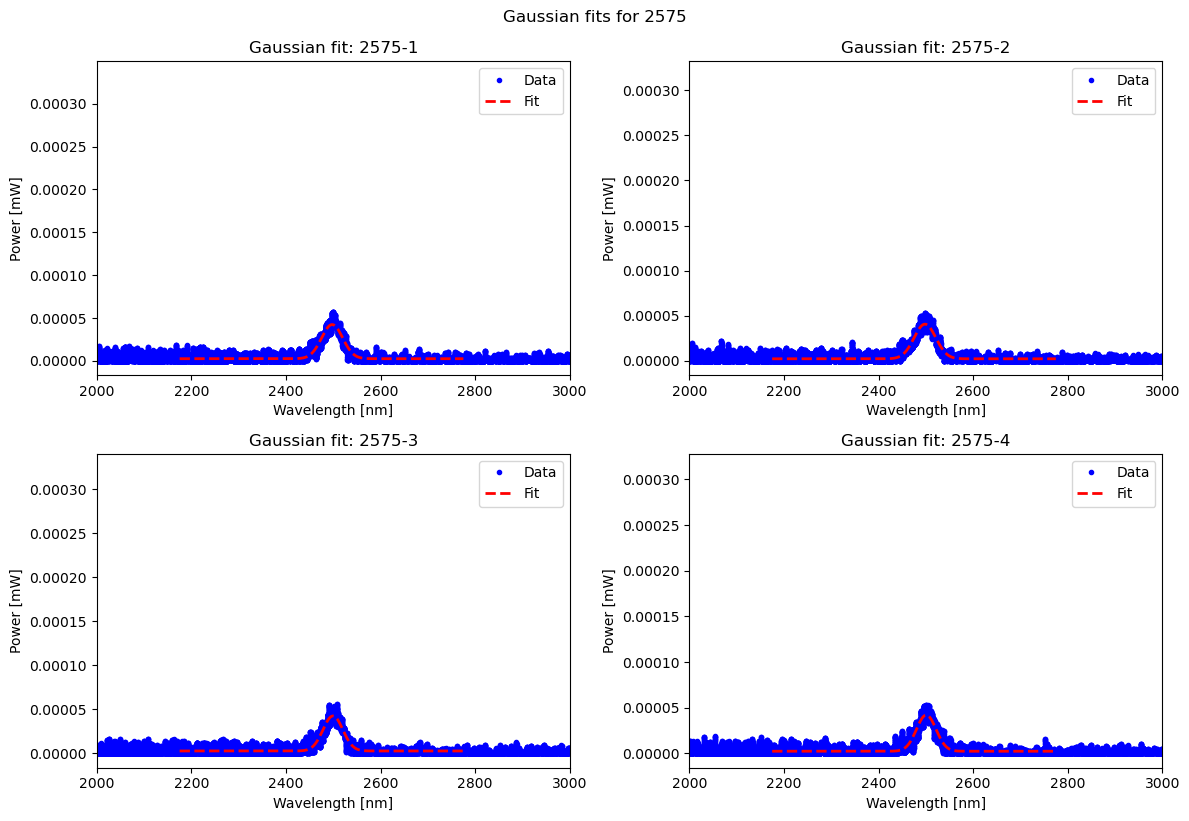

Summary for set 2575:
Mean x0    = 2499.0071 ± 0.0548
Mean sigma = 21.7436 ± 0.0544
  sigma = 30.1792 ± 0.1265
  sigma = 31.3840 ± 0.1442
  sigma = 31.4138 ± 0.1496
  sigma = 30.1764 ± 0.1271


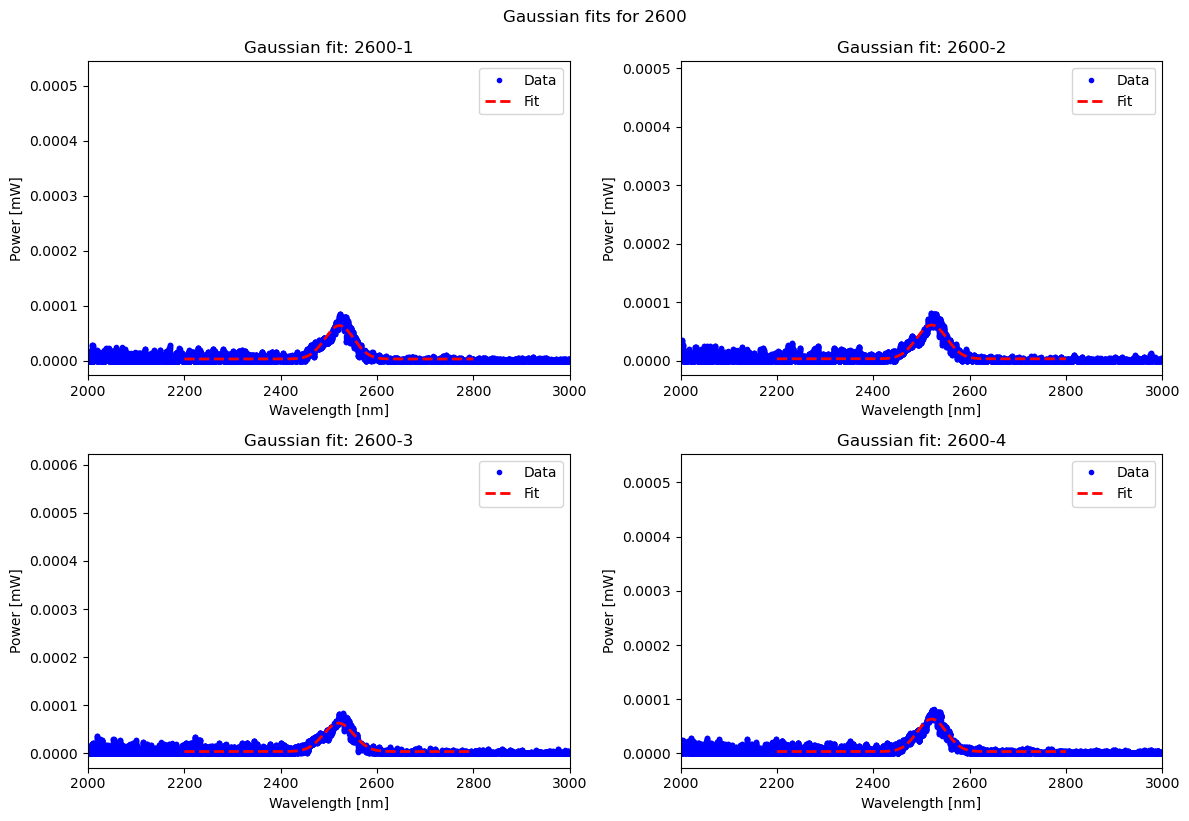

Summary for set 2600:
Mean x0    = 2521.2456 ± 0.0654
Mean sigma = 30.6993 ± 0.0679
  sigma = 29.7172 ± 0.1130
  sigma = 30.7300 ± 0.1196
  sigma = 31.7780 ± 0.1284
  sigma = 29.7629 ± 0.1082


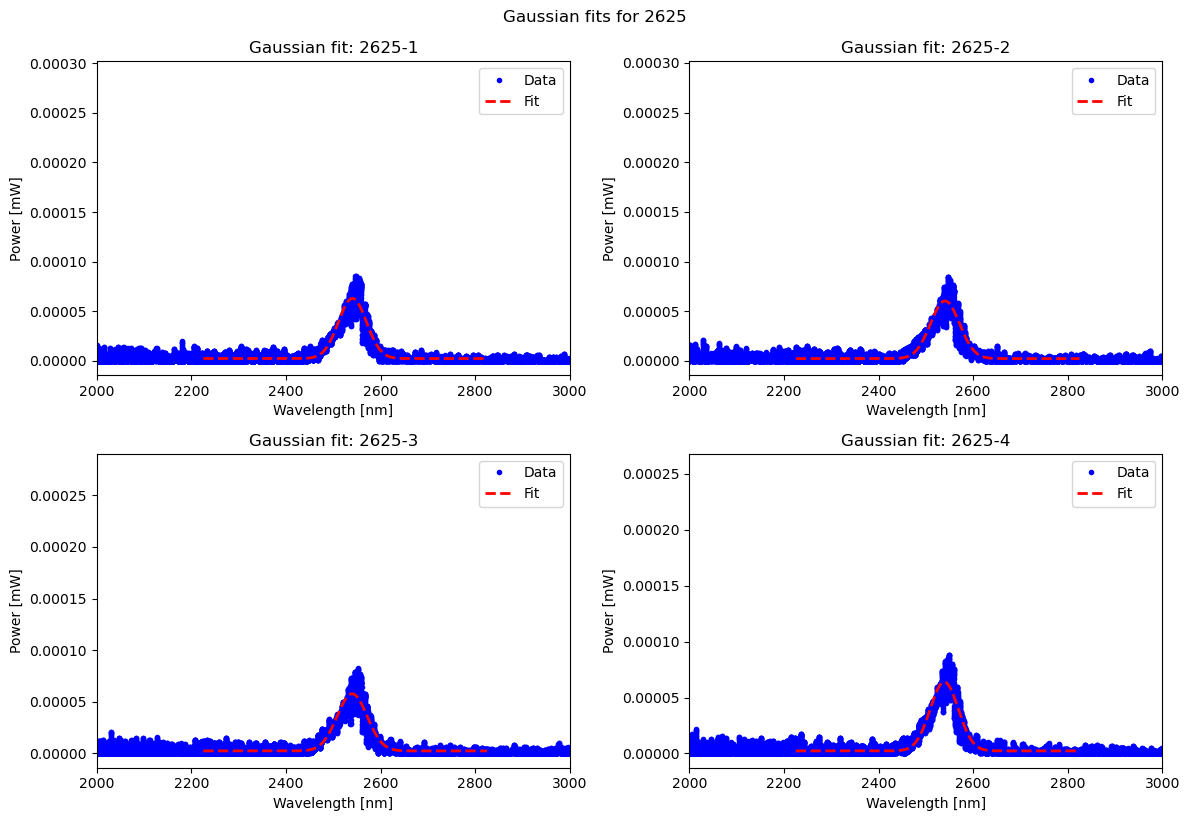

Summary for set 2625:
Mean x0    = 2539.9072 ± 0.0593
Mean sigma = 30.3959 ± 0.0583
  sigma = 32.5948 ± 0.1456
  sigma = 33.2948 ± 0.1632
  sigma = 32.5605 ± 0.1420
  sigma = 32.9281 ± 0.1570


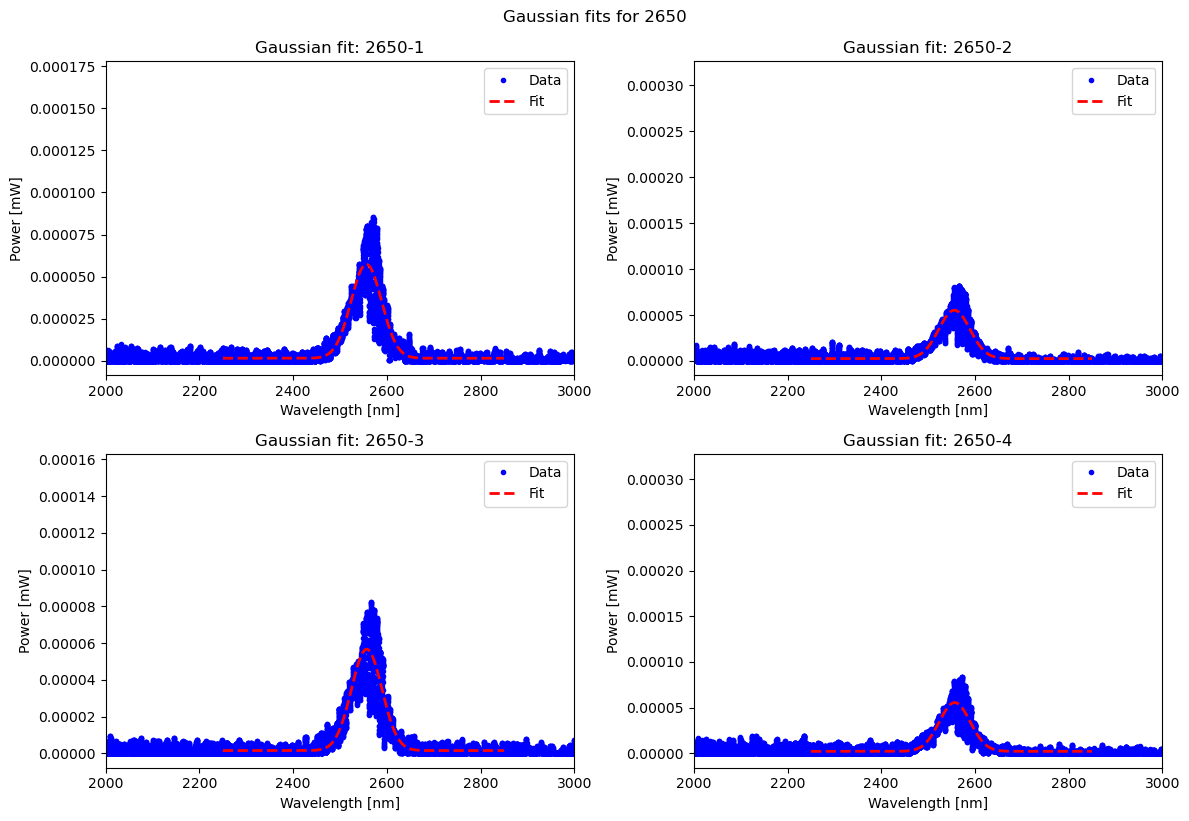

Summary for set 2650:
Mean x0    = 2556.6231 ± 0.0757
Mean sigma = 32.8127 ± 0.0756
  sigma = 36.0407 ± 0.1867
  sigma = 36.0265 ± 0.1948
  sigma = 35.9887 ± 0.1879
  sigma = 36.2741 ± 0.1887


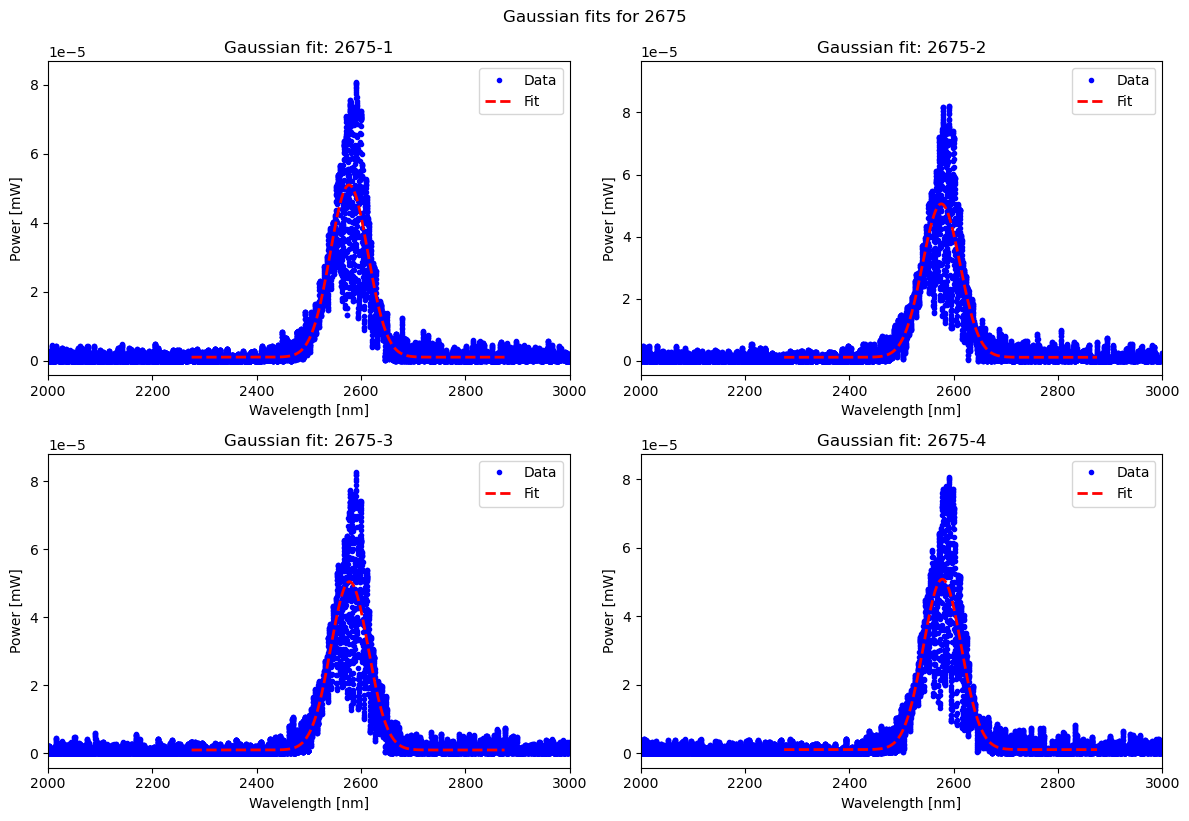

Summary for set 2675:
Mean x0    = 2577.3615 ± 0.0915
Mean sigma = 36.0830 ± 0.0947
  sigma = 38.0755 ± 0.2343
  sigma = 38.2029 ± 0.2332
  sigma = 38.6170 ± 0.2301
  sigma = 38.9634 ± 0.2410


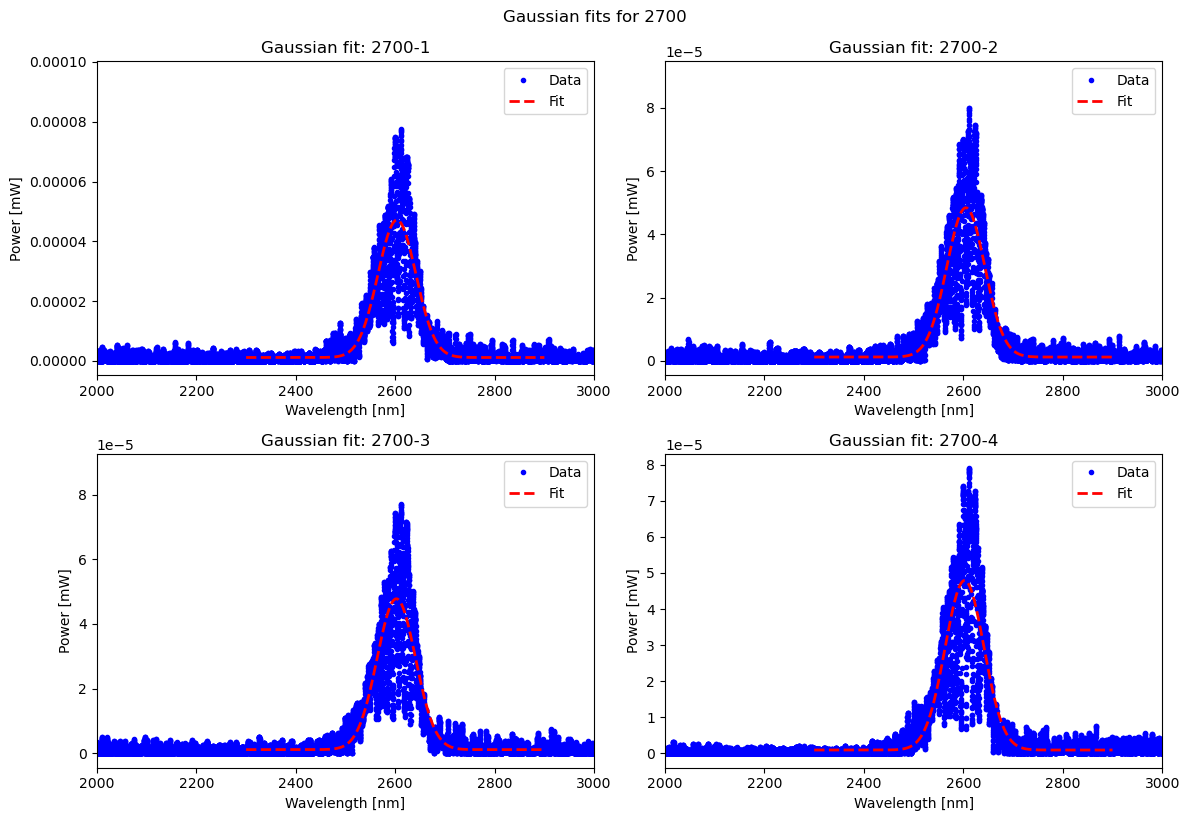

Summary for set 2700:
Mean x0    = 2603.2658 ± 0.1112
Mean sigma = 38.4586 ± 0.1173
  sigma = 28.4759 ± 0.1756
  sigma = 28.9739 ± 0.1845
  sigma = 29.0706 ± 0.1819
  sigma = 28.9240 ± 0.1772


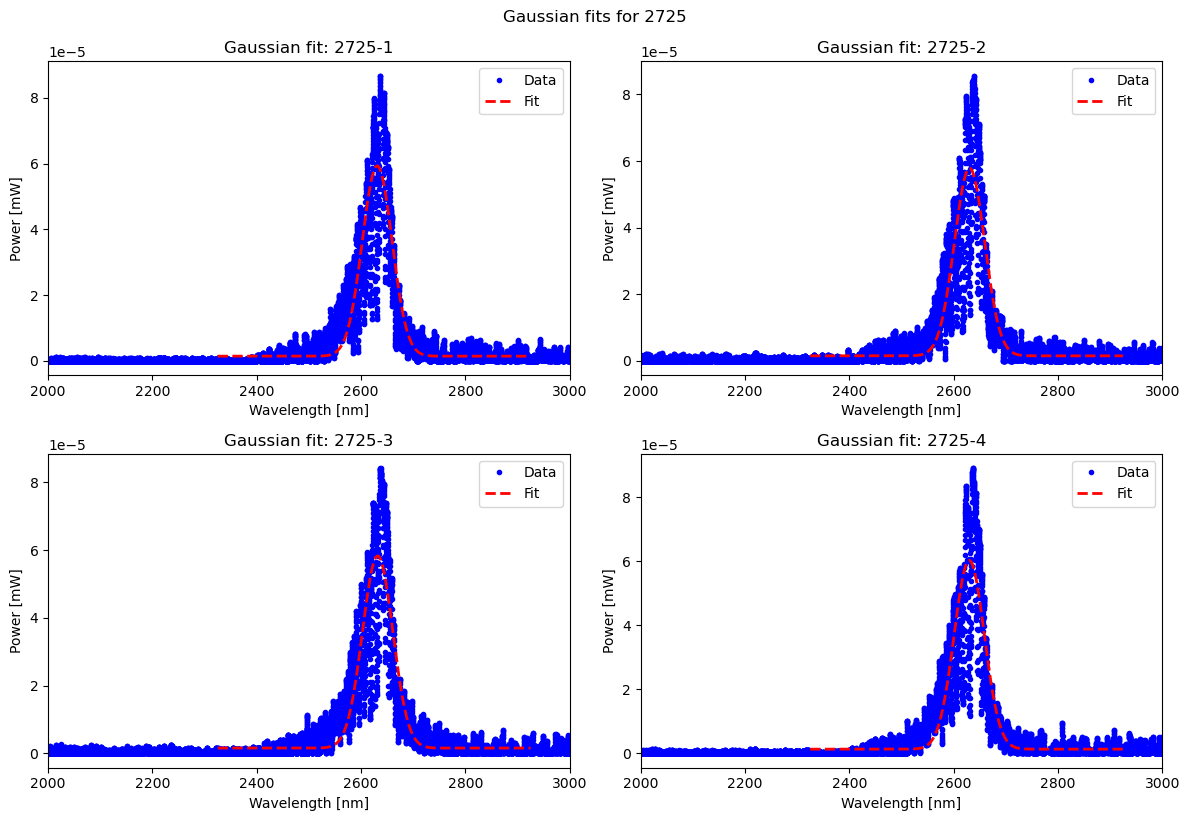

Summary for set 2725:
Mean x0    = 2630.7630 ± 0.0866
Mean sigma = 28.8543 ± 0.0898
  sigma = 29.8945 ± 0.1798
  sigma = 29.4716 ± 0.1737
  sigma = 29.9958 ± 0.1858
  sigma = 29.8571 ± 0.1813


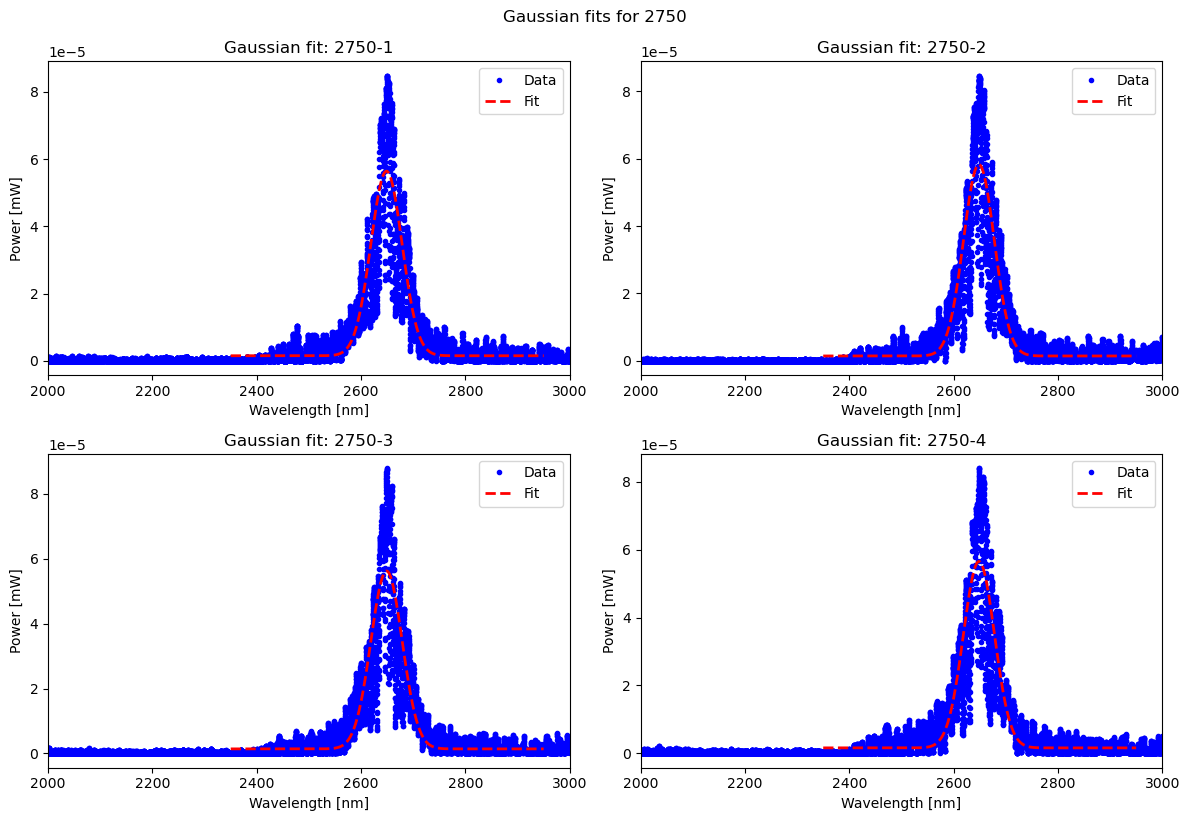

Summary for set 2750:
Mean x0    = 2648.5984 ± 0.0864
Mean sigma = 29.7955 ± 0.0900
  sigma = 38.8427 ± 0.2566
  sigma = 39.1829 ± 0.2561
  sigma = 38.6493 ± 0.2421
  sigma = 39.3018 ± 0.2641


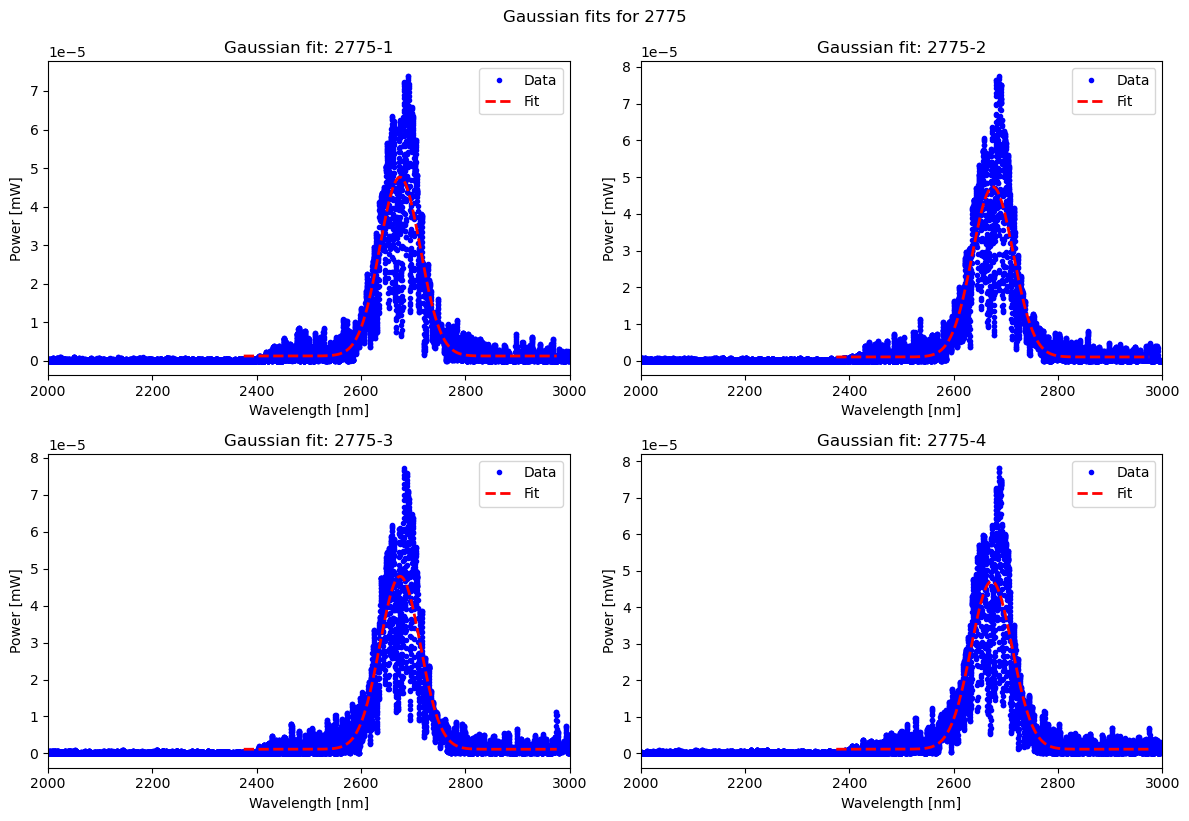

Summary for set 2775:
Mean x0    = 2674.3940 ± 0.1199
Mean sigma = 38.9796 ± 0.1272
  sigma = 36.7113 ± 0.2599
  sigma = 36.1552 ± 0.2533
  sigma = 35.6517 ± 0.2556
  sigma = 35.4915 ± 0.2552


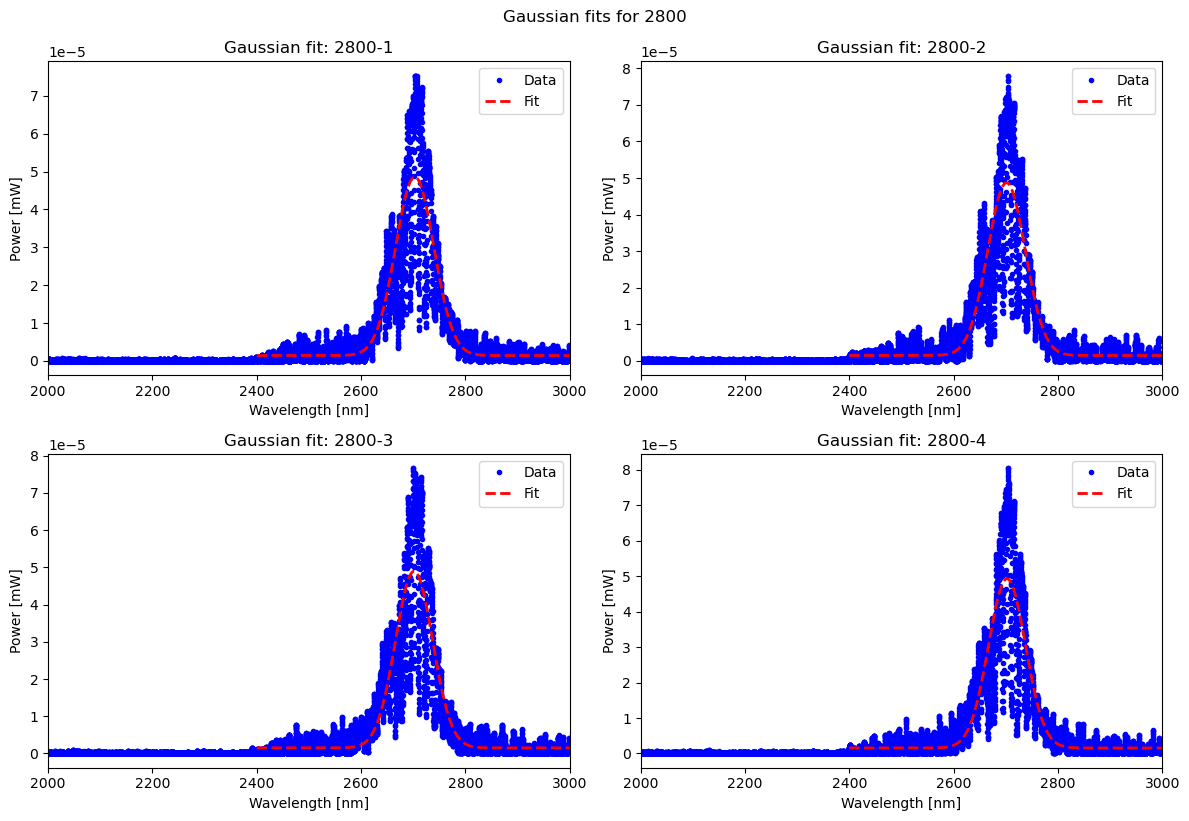

Summary for set 2800:
Mean x0    = 2702.0180 ± 0.1211
Mean sigma = 35.9969 ± 0.1280
  sigma = 36.1217 ± 0.2621
  sigma = 35.5353 ± 0.2450
  sigma = 36.4140 ± 0.2568
  sigma = 36.0471 ± 0.2540


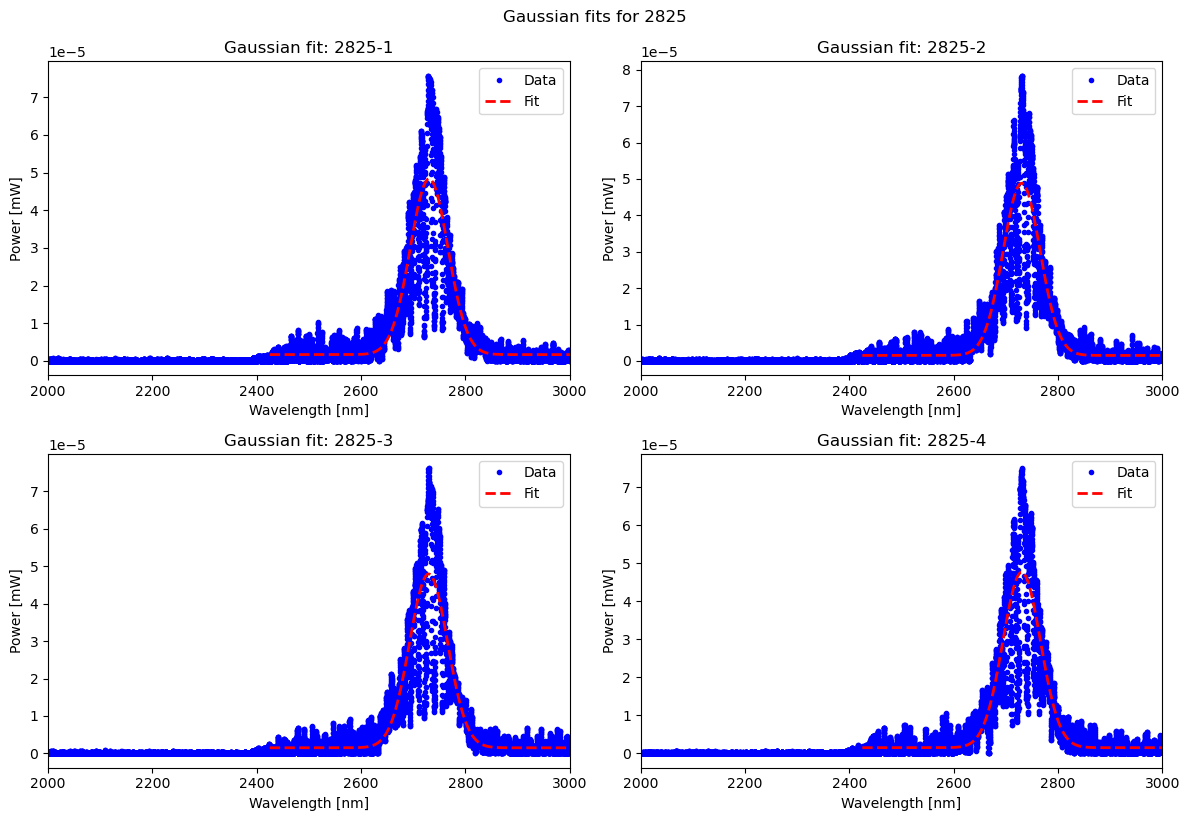

Summary for set 2825:
Mean x0    = 2730.1683 ± 0.1199
Mean sigma = 36.0168 ± 0.1271
  sigma = 35.3870 ± 0.1699
  sigma = 40.6387 ± 0.2510
  sigma = 41.2436 ± 0.2639
  sigma = 41.0897 ± 0.2591


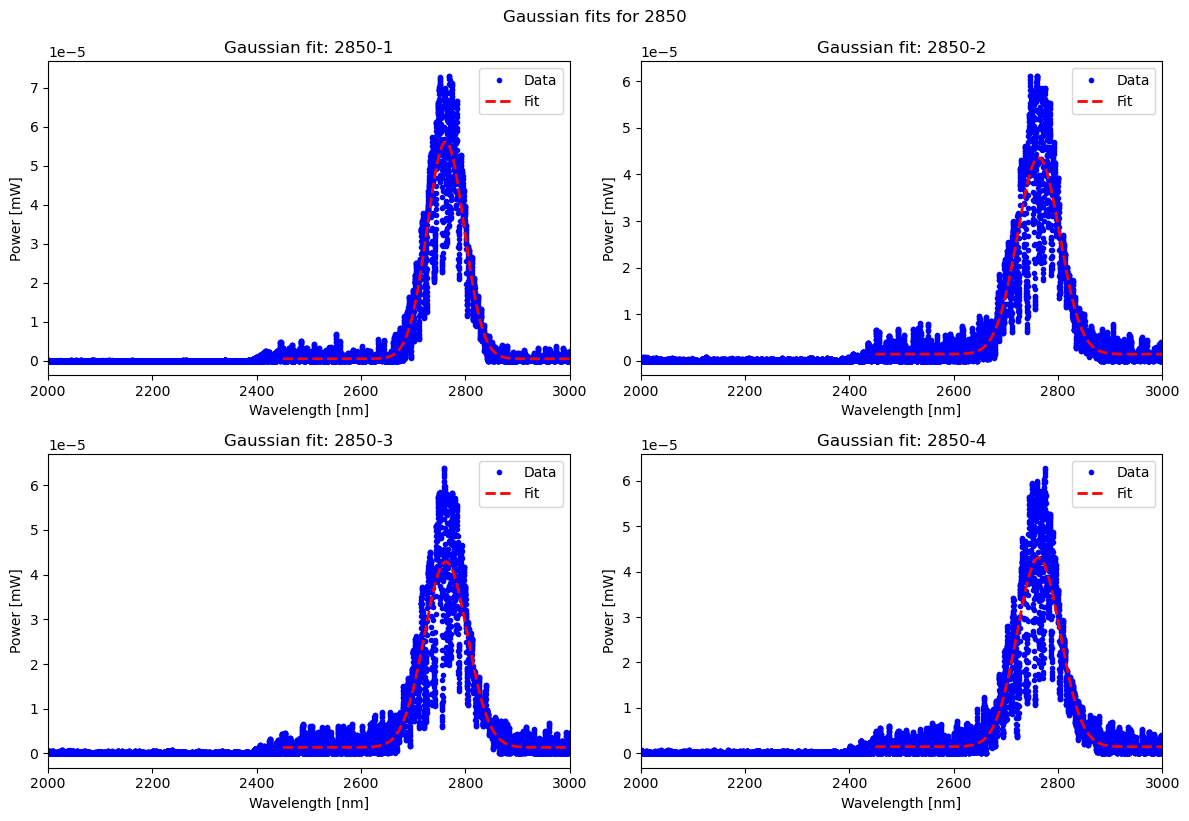

Summary for set 2850:
Mean x0    = 2762.5505 ± 0.1046
Mean sigma = 38.5506 ± 0.1120
  sigma = 38.5531 ± 0.2041
  sigma = 37.0395 ± 0.1779
  sigma = 35.6755 ± 0.1623
  sigma = 39.0655 ± 0.1979


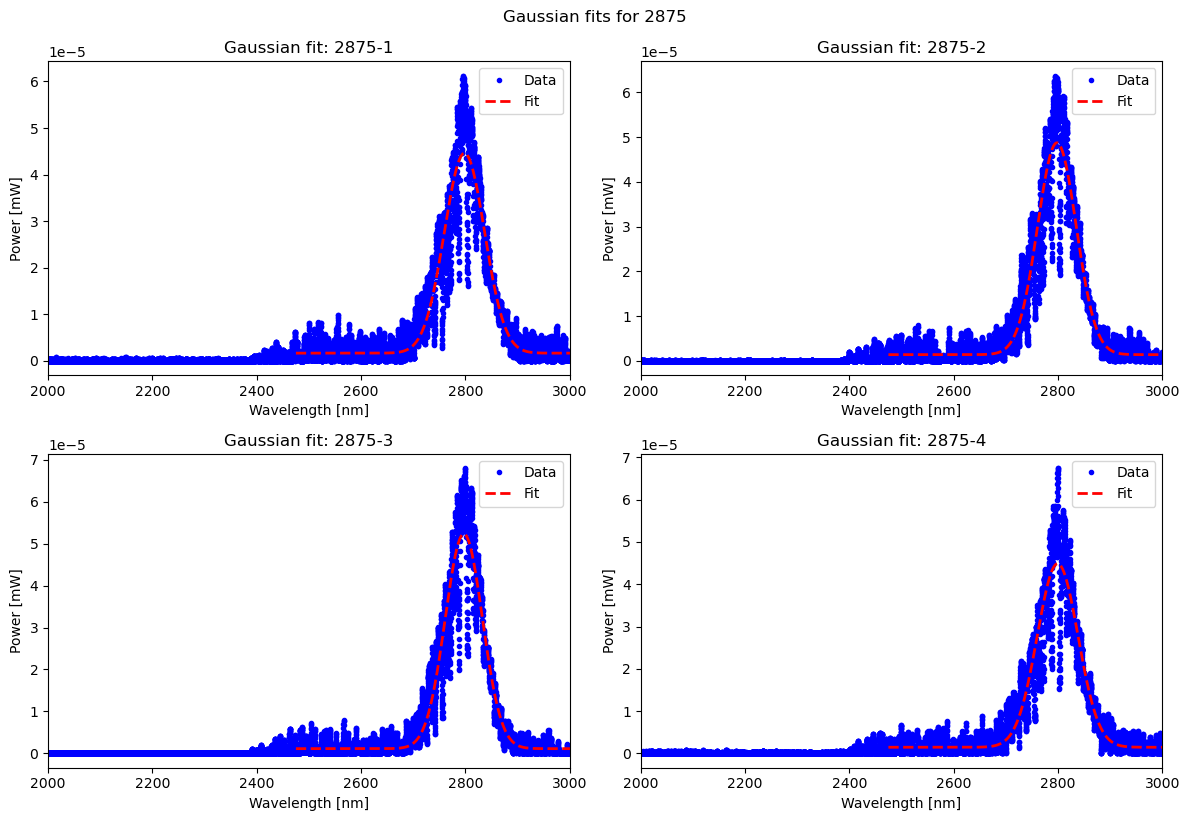

Summary for set 2875:
Mean x0    = 2798.0240 ± 0.0856
Mean sigma = 37.3441 ± 0.0916
  sigma = 37.8679 ± 0.1495
  sigma = 37.4271 ± 0.1486
  sigma = 38.0411 ± 0.1453
  sigma = 37.6378 ± 0.1482


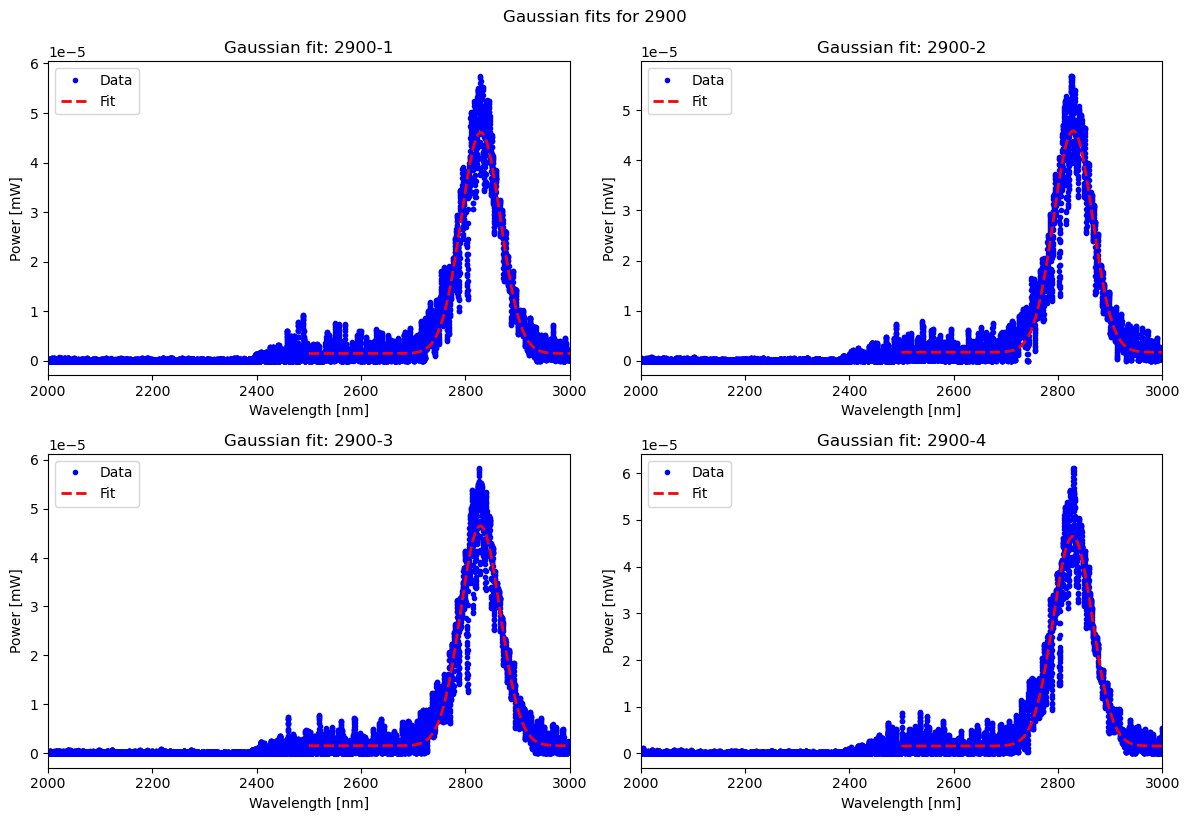

Summary for set 2900:
Mean x0    = 2828.9041 ± 0.0687
Mean sigma = 37.7463 ± 0.0739

Saved summary to fit_summary.csv


In [3]:
# --- Storage for summary results ---
summary = []

# Loop over all sets from 2550 to 2900 in steps of 25
for number in range(2550, 2901, 25):
    files = [os.path.join(path, f"{number}-{i}.txt") for i in range(1,5)]
    c = number - 100
    xmin, xmax = c - 300, c + 300

    x0_vals, x0_errs = [], []
    sigma_vals, sigma_errs = [], []

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for idx, file in enumerate(files):
        # Load data
        data = np.loadtxt(file, delimiter=";")
        x, y = data[:,0], data[:,1]

        # Restrict to fitting range
        mask = (x >= xmin) & (x <= xmax)
        x_fit, y_fit = x[mask], y[mask]

        # Initial guesses
        p0 = [max(y_fit), c, 20, min(y_fit)]

        try:
            popt, pcov = curve_fit(gauss, x_fit, y_fit, p0=p0)
            perr = np.sqrt(np.diag(pcov))
        except RuntimeError:
            print(f"Fit did not converge for {file}")
            continue

        # Save parameters
        x0_vals.append(popt[1])
        x0_errs.append(perr[1])
        sigma_vals.append(popt[2])
        sigma_errs.append(perr[2])

        # Print fitted parameters
        #print("File:", os.path.basename(file))
        #print("  a     = {:.4f} ± {:.4f}".format(popt[0], perr[0]))
        #print("  x0    = {:.4f} ± {:.4f}".format(popt[1], perr[1]))
        print("  sigma = {:.4f} ± {:.4f}".format(popt[2], perr[2]))
        #print("  y0    = {:.4f} ± {:.4f}".format(popt[3], perr[3]))
        #print()

        # Plot raw data + fit
        ax = axes[idx]
        ax.plot(x, y, 'b.', label="Data")
        x_dense = np.linspace(xmin, xmax, 500)
        ax.plot(x_dense, gauss(x_dense, *popt), 'r--', linewidth=2, label="Fit")
        ax.set_xlabel("Wavelength [nm]")
        ax.set_ylabel("Power [mW]")
        ax.set_xlim(2000, 3000)
        ax.set_title(f"Gaussian fit: {os.path.basename(file).replace('.txt','')}")
        ax.legend()

    plt.tight_layout()
    plt.suptitle(f"Gaussian fits for {number}", y=1.02)
    plt.show()

    if x0_vals:
        mean_x0, err_x0 = weighted_mean(np.array(x0_vals), np.array(x0_errs))
        mean_sigma, err_sigma = weighted_mean(np.array(sigma_vals), np.array(sigma_errs))
        print("Summary for set {}:".format(number))
        print("Mean x0    = {:.4f} ± {:.4f}".format(mean_x0, err_x0))
        print("Mean sigma = {:.4f} ± {:.4f}".format(mean_sigma, err_sigma))

        summary.append({
            "set": number,
            "mean_x0": mean_x0,
            "err_x0": err_x0,
            "mean_sigma": mean_sigma,
            "err_sigma": err_sigma
        })

# Save summary results to CSV
summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(path, "fit_summary.csv"), index=False)
print("\nSaved summary to fit_summary.csv")

## Relation of wavelengths

C:\Users\miria\AppData\Local\Temp\ipykernel_39540\2220620780.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x_fit, linear(x_fit, *popt), 'r-', label=f"Fit: y={popt[0]:.2f}x{intercept_str}", color="navy")


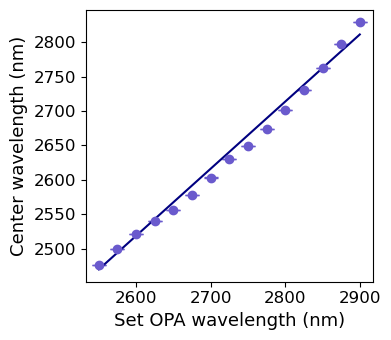

Linear fit results:
Slope m     = 0.976212 ± 0.000163
Intercept b = -19.670686 ± 0.437287


In [13]:
# Load the summary CSV created in the last step
summary_df = pd.read_csv(os.path.join(path, "fit_summary.csv"))

# Plot mean_x0 vs set wavelength with errorbars
plt.figure(figsize=(4,3.5))
plt.errorbar(summary_df["set"], summary_df["mean_x0"], yerr=summary_df["err_x0"], fmt='o', capsize=5, label="Data", color="slateblue")
plt.xlabel("Set OPA wavelength (nm)", fontsize='13')
plt.ylabel("Center wavelength (nm)", fontsize='13')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Perform linear fit (y = m*x + b)
def linear(x, m, b):
    return m*x + b

popt, pcov = curve_fit(linear, summary_df["set"], summary_df["mean_x0"], sigma=summary_df["err_x0"], absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

# Plot fit line
x_fit = np.linspace(summary_df["set"].min(), summary_df["set"].max(), 500)
intercept_str = f"{popt[1]:.2f}" if popt[1] < 0 else f"+{popt[1]:.2f}"
plt.plot(x_fit, linear(x_fit, *popt), 'r-', label=f"Fit: y={popt[0]:.2f}x{intercept_str}", color="navy")

#plt.legend()
#plt.grid()
plt.tight_layout()
plt.savefig("wavelengths.pdf")
plt.show()

print("Linear fit results:")
print("Slope m     = {:.6f} ± {:.6f}".format(popt[0], perr[0]))
print("Intercept b = {:.6f} ± {:.6f}".format(popt[1], perr[1]))


## FWHM

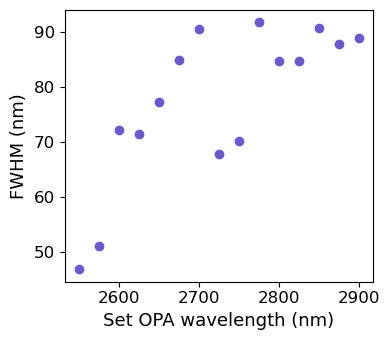

Linear fit results:
Slope m     = 0.976212 ± 0.000163
Intercept b = -19.670686 ± 0.437287


In [14]:
# Load the summary CSV created in the last step
summary_df = pd.read_csv(os.path.join(path, "fit_summary.csv"))

# Plot mean_x0 vs set wavelength with errorbars
plt.figure(figsize=(4,3.5))
plt.scatter(summary_df["set"], 2 * np.sqrt(2 * np.log(2))* summary_df["mean_sigma"], label="Data", color="slateblue")
plt.xlabel("Set OPA wavelength (nm)", fontsize='13')
plt.ylabel("FWHM (nm)", fontsize='13')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig("FWHM.pdf")
plt.show()

print("Linear fit results:")
print("Slope m     = {:.6f} ± {:.6f}".format(popt[0], perr[0]))
print("Intercept b = {:.6f} ± {:.6f}".format(popt[1], perr[1]))